In [2]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.0 kB)
  Using cached nvidia_nccl_cu12-2.30.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.3.0-py3-none-manylinux_2_28_x86_64.whl (98.7 MB)
Using cached nvidia_nccl_cu12-2.30.7-py3-none-manylinux_2_18_x86_64.whl (303.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("ENDES_Anemia_Hogar_2019_2024_LIMPIO.csv")

# Codificar variables categóricas a números
le_area = LabelEncoder()
le_depto = LabelEncoder()

df['Area_cod']  = le_area.fit_transform(df['Area_Residencia'].fillna('Desconocido'))
df['Depto_cod'] = le_depto.fit_transform(df['Departamento'].fillna('Desconocido'))

# Variable objetivo
df['target_binario'] = (df['Nivel_Anemia'] != 'Sin anemia').astype(int)

print("Clases:",  df['target_binario'].value_counts().to_dict())
print("Total registros:", len(df))

Clases: {0: 69554, 1: 35473}
Total registros: 105027


In [3]:
#TRAIN
# Seleccionar las variables que usará el modelo
features = ['Edad_Meses', 'Peso_kg', 'Talla_cm',
            'Zscore_Talla_Edad', 'Zscore_Peso_Edad', 'Zscore_Peso_Talla', 'Zscore_IMC',
            'Altitud', 'Area_cod', 'Depto_cod']

X = df[features].dropna()
y = df.loc[X.index, 'target_binario']

print("Datos listos:", X.shape)

Datos listos: (105027, 10)


In [4]:
#RANDOM FOREST

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# BALANCEO DE CLASES CON SMOTE
# SMOTE genera ejemplos sintéticos de la clase minoritaria (Con anemia)
# interpolando entre casos reales, hasta igualar ambas clases.
#sm = SMOTE(random_state=42)
#X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

#print("Antes de SMOTE:", y_train.value_counts().to_dict())
#print("Después de SMOTE:", pd.Series(y_train_res).value_counts().to_dict())


# Crear y entrenar modelo 
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
modelo_rf.fit(X_train, y_train) # modficado  X_train_res 

preds_rf = modelo_rf.predict(X_test)

print("Modelo Random Forest listo")

Modelo Random Forest listo


In [5]:
# XGBOOST
from xgboost import XGBClassifier

# Crear y entrenar el modelo con los mejores parámetros
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)
modelo_xgb.fit(X_train, y_train) # modficado  X_train_res 

preds_xgb = modelo_xgb.predict(X_test)

print("Modelo XGBoost listo")

Modelo XGBoost listo


In [6]:
# Métricas Random Forest
acc_rf       = accuracy_score(y_test, preds_rf)
f1_rf        = f1_score(y_test, preds_rf, average='macro')
f1_rf_anemia = f1_score(y_test, preds_rf, pos_label=1)

# Métricas XGBoost
acc_xgb       = accuracy_score(y_test, preds_xgb)
f1_xgb        = f1_score(y_test, preds_xgb, average='macro')
f1_xgb_anemia = f1_score(y_test, preds_xgb, pos_label=1)

# Mostrar comparación
print("COMPARACIÓN DE MODELOS")
print(f"Accuracy      - Random Forest: {acc_rf:.4f}  |  XGBoost: {acc_xgb:.4f}")
print(f"F1-macro      - Random Forest: {f1_rf:.4f}  |  XGBoost: {f1_xgb:.4f}")
print(f"F1-Con anemia - Random Forest: {f1_rf_anemia:.4f}  |  XGBoost: {f1_xgb_anemia:.4f}")

COMPARACIÓN DE MODELOS
Accuracy      - Random Forest: 0.6935  |  XGBoost: 0.7184
F1-macro      - Random Forest: 0.6718  |  XGBoost: 0.6524
F1-Con anemia - Random Forest: 0.5875  |  XGBoost: 0.5010


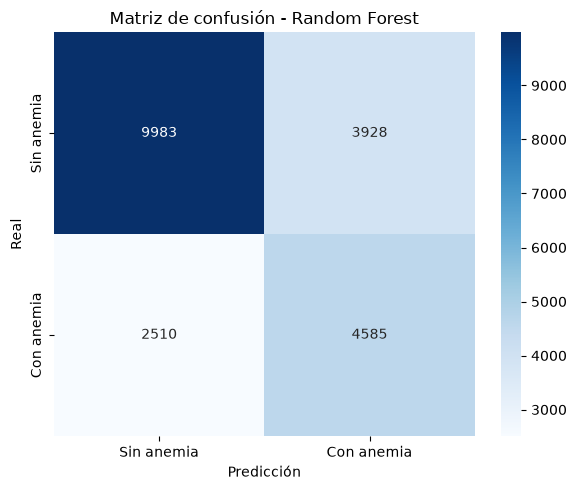

In [7]:
# Matriz de confusión del mejor modelo (Random Forest)
cm = confusion_matrix(y_test, preds_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin anemia', 'Con anemia'],
            yticklabels=['Sin anemia', 'Con anemia'])
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

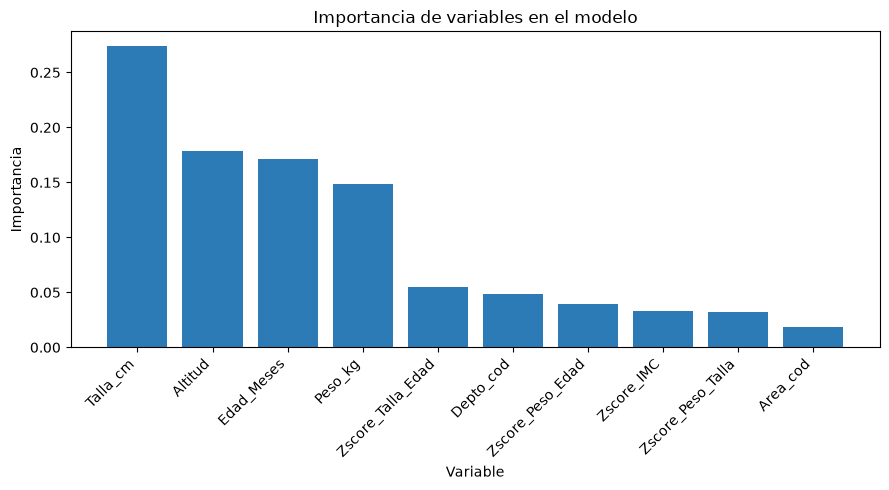

In [8]:
# Importancia de cada variable en el modelo
importancias = pd.Series(modelo_rf.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(importancias.index, importancias.values, color='#2C7BB6')
plt.title('Importancia de variables en el modelo')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Ajustar umbral: en vez de 0.5 usamos 0.35
y_prob = modelo_rf.predict_proba(X_test)[:, 1]
y_pred_ajustado = (y_prob >= 0.35).astype(int)

print("Con umbral ajustado (0.35):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ajustado), 4))
print("\nReporte completo:")
print(classification_report(y_test, y_pred_ajustado, target_names=['Sin anemia', 'Con anemia']))

Con umbral ajustado (0.35):
Accuracy: 0.5876

Reporte completo:
              precision    recall  f1-score   support

  Sin anemia       0.85      0.46      0.59     13911
  Con anemia       0.44      0.85      0.58      7095

    accuracy                           0.59     21006
   macro avg       0.65      0.65      0.59     21006
weighted avg       0.71      0.59      0.59     21006



In [10]:
# Función del agente inteligente
def agente_anemia(edad_meses, peso_kg, talla_cm, zscore_talla_edad,
                  zscore_peso_edad, zscore_peso_talla, zscore_imc,
                  altitud, area, departamento):

    # Codificar área y departamento
    area_cod  = le_area.transform([area])[0]
    depto_cod = le_depto.transform([departamento])[0]

    #  datos del niño
    datos = pd.DataFrame([[edad_meses, peso_kg, talla_cm, zscore_talla_edad,
                           zscore_peso_edad, zscore_peso_talla, zscore_imc,
                           altitud, area_cod, depto_cod]], columns=features)

    # Predecir probabilidad de anemia
    probabilidad = modelo_rf.predict_proba(datos)[0][1]
    prediccion   = 'Con anemia' if probabilidad >= 0.35 else 'Sin anemia'

    # Recomendaciones
    print("=" * 45)
    print("   AGENTE DE DETECCIÓN DE ANEMIA INFANTIL")
    print("=" * 45)
    print(f"Resultado    : {prediccion}")
    print(f"Probabilidad : {probabilidad:.1%}")
    print("-" * 45)

    if prediccion == 'Con anemia':
        print("⚠️  RECOMENDACIONES:")
        print("  - Realizar medición de hemoglobina urgente")
        print("  - Derivar al centro de salud más cercano")
        print("  - Aumentar consumo de alimentos con hierro")
        print("    (sangrecita, hígado, lentejas, espinaca)")
        print("  - Evitar té o café junto a las comidas")
    else:
        print("✅  RECOMENDACIONES:")
        print("  - Continuar con controles de crecimiento")
        print("  - Mantener dieta variada y nutritiva")
        print("  - Próxima evaluación en 6 meses")

    print("=" * 45)

In [11]:
# Prueba del agente con un niño de ejemplo
agente_anemia(
    edad_meses       = 24,
    peso_kg          = 12.5,
    talla_cm         = 87.0,
    zscore_talla_edad= 1.0,
    zscore_peso_edad = 1.8,
    zscore_peso_talla= 1.3,
    zscore_imc       = 1.0,
    altitud          = 50,
    area             = 'Urbana',
    departamento     = 'Lima'
)

   AGENTE DE DETECCIÓN DE ANEMIA INFANTIL
Resultado    : Sin anemia
Probabilidad : 34.9%
---------------------------------------------
✅  RECOMENDACIONES:
  - Continuar con controles de crecimiento
  - Mantener dieta variada y nutritiva
  - Próxima evaluación en 6 meses


In [12]:
import joblib

joblib.dump(modelo_rf, 'modelo_rf.pkl')
joblib.dump(le_area,   'le_area.pkl')
joblib.dump(le_depto,  'le_depto.pkl')

print("Archivos guardados:")
print("- modelo_rf.pkl")
print("- le_area.pkl")
print("- le_depto.pkl")

Archivos guardados:
- modelo_rf.pkl
- le_area.pkl
- le_depto.pkl
